# SMM Estimation
Structural estimation of `FullLaborModelClass` via Simulated Method of Moments.

**Workflow**
1. Initialise model and estimator  
2. Set starting values `theta0`  
3. Load data moments  
4. Verify moment function at `theta0`  
5. Run estimation (Nelder-Mead)  
6. Plot simulated vs empirical hazards  
7. Inspect parameter estimates

## 1. Setup

In [67]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from DynLaborSickModel import FullLaborModelClass
from Estimation import SMMEstimator, make_data_moments, make_weight_matrix, moment_fit_table, PARAM_SPEC 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 2. Initialise estimator

In [68]:

est = SMMEstimator(
    FullLaborModelClass,
    calibrated = {
        'beta':    0.98,
        'tau':     0.30,
        'Ubar':    24,
        'alpha':   0.10,   # calibrated from Mincer wage regression
        'delta_k': 0.05,   # calibrated depreciation rate
    },
)

pd.DataFrame(PARAM_SPEC, columns=['name','lower','upper','description'])


,name,lower,upper,description
0,gamma,0.30,2.500,search cost curvature
1,iota,0.30,2.500,work disutility curvature
2,chi,0.00,6.000,participation cost coefficient
3,rho_h,0.50,0.995,health AR(1) persistence
4,sigma_h,0.05,1.200,health shock std dev
5,delta_h_S,-0.10,1.000,health recovery drift on sick leave
6,delta0_doc,-0.20,0.600,medical gate intercept
7,delta1_doc,-1.00,2.000,medical gate slope (health)
8,delta2_doc,-2.00,2.000,medical gate curvature (health²)
9,b_sick_low,0.20,0.950,intermediate benefit post-reassessment


## 3. Starting values
Set `theta0` to the default model parameter values.  
Adjust individual entries here before running estimation.

In [69]:

_m = FullLaborModelClass()
_m.setup()
_p = _m.par

theta0 = np.array([
    _p.gamma,          # search cost curvature
    _p.iota,           # work disutility curvature
    _p.chi,            # participation cost coefficient
    _p.rho_h,          # health AR(1) persistence
    _p.sigma_h,        # health shock std dev
    _p.delta_h_S,      # health recovery drift on sick leave
    _p.delta0_doc,     # medical gate intercept
    _p.delta1_doc,     # medical gate slope (health)
    _p.delta2_doc,     # medical gate curvature (health²)
    _p.b_sick_low,     # intermediate benefit post-reassessment
    _p.delta0_low,     # P(reduced benefit | h) intercept
    _p.delta1_low,     # P(reduced benefit | h) slope
    _p.delta2_low,     # P(reduced benefit | h) curvature
    _p.delta0_out,     # P(kicked out | h) intercept
    _p.delta1_out,     # P(kicked out | h) slope
    _p.delta2_out,     # P(kicked out | h) curvature
    _p.lambda_grid[0], # search cost scale type 0
    _p.lambda_grid[1], # search cost scale type 1
    _p.nu_grid[0],     # work disutility scale type 0
    _p.nu_grid[1],     # work disutility scale type 1
    _p.type_shares[1], # population share of type 1
    _p.h_init_mu[1],   # initial health z-shift type 1
])

# Print starting values alongside bounds
spec = pd.DataFrame(PARAM_SPEC, columns=['name','lower','upper','description'])
spec.insert(1, 'theta0', theta0)
spec


,name,theta0,lower,upper,description
0,gamma,0.900,0.30,2.500,search cost curvature
1,iota,0.900,0.30,2.500,work disutility curvature
2,chi,1.000,0.00,6.000,participation cost coefficient
3,rho_h,0.915,0.50,0.995,health AR(1) persistence
4,sigma_h,0.300,0.05,1.200,health shock std dev
5,delta_h_S,0.060,-0.10,1.000,health recovery drift on sick leave
6,delta0_doc,0.150,-0.20,0.600,medical gate intercept
7,delta1_doc,0.900,-1.00,2.000,medical gate slope (health)
8,delta2_doc,0.000,-2.00,2.000,medical gate curvature (health²)
9,b_sick_low,0.500,0.20,0.950,intermediate benefit post-reassessment


## 4. Data moments
Load empirical hazard rates.  Add more moment DataFrames here as they become available —
anything left `None` is automatically excluded from the objective.

In [70]:
# ── U→E and U→S ──────────────────────────────────────────────────────────                                                                                                                             
_ue = pd.read_csv('hazard_UE.csv')                                                                                                                                                                      
_us = pd.read_csv('hazard_US.csv')
                                                                                                                                                                                                        
# ── S→E and S→U (replaces hazard_monthly.csv + weight_monthly.csv) ───────                                                                                                                             
_se = pd.read_csv('hazard_SE.csv')
_su = pd.read_csv('hazard_SU.csv')
_se = _se[_se['hazard'] > 0].rename(columns={'duration_m': 'duration'})
_su = _su[_su['hazard'] > 0].rename(columns={'duration_m': 'duration'})
_se['duration'] = _se['duration'].round().astype(int)
_su['duration'] = _su['duration'].round().astype(int)
# Keep only one row per integer month (first occurrence after rounding)
_se = _se.drop_duplicates('duration')
_su = _su.drop_duplicates('duration')                                                                                                                                                                     

est_t = 30

_ue = _ue[_ue['hazard'] > 0].rename(columns={'anc_ved_afgang': 'duration'})
_us = _us[_us['hazard'] > 0].rename(columns={'anc_ved_afgang': 'duration'})                                                                                                                                                                                                        
_ue = _ue[_ue['duration'] > 0].reset_index(drop=True)                                                                                                                                                                        
_us = _us[_us['duration'] > 0].reset_index(drop=True)
_ue = _ue[_ue['duration'] <= est_t].reset_index(drop=True)                                                                                                                                                                        
_us = _us[_us['duration'] <= est_t].reset_index(drop=True)                                                                                                                                                                            

_se = _se[_se['duration'] <= est_t].reset_index(drop=True)                                                                                                                                                                        
_su = _su[_su['duration'] <= est_t].reset_index(drop=True)
                                                                                                                                                                                                        
# ── Build data moments ────────────────────────────────────────────────────
data_moments = make_data_moments(                                                                                                                                                                       
    hz_ue_df = _ue[['duration', 'hazard']],                                                                                                                                                             
    hz_us_df = _us[['duration', 'hazard']],                                                                                                                                                             
    hz_se_df = _se[['duration', 'hazard']],                                                                                                                                                             
    hz_su_df = _su[['duration', 'hazard']],                                                                                                                                                             
)                                                                                                                                                                                                       

# ── Build SE dict and weight matrix (1/se²) ───────────────────────────────                                                                                                                            
se_dict = {}    
for prefix, _df in [('hz_ue', _ue), ('hz_us', _us), ('hz_se', _se), ('hz_su', _su)]:                                                                                                                    
    for _, row in _df.iterrows():                                                                                                                                                                       
        se_dict[f"{prefix}_d{int(row['duration']):02d}"] = row['hazard_se']                                                                                                                             
                                                                                                                                                                                                        
W_se = make_weight_matrix(se_dict, data_moments)                                                                                                                                                        
                                                                                                                                                                                                        
print(f'{len(data_moments)} moments loaded, {len(se_dict)} with standard errors') 

# ── Build CI dict from all hazard files ───────────────────────────────────
ci_dict = {}
for prefix, _df in [('hz_ue', _ue), ('hz_us', _us), ('hz_se', _se), ('hz_su', _su)]:
    for _, row in _df.iterrows():
        k = f"{prefix}_d{int(row['duration']):02d}"
        ci_dict[k] = (row['hazard_lower'], row['hazard_upper'])

120 moments loaded, 111 with standard errors


## 5. Verify moment function at starting values
Runs the model once at `theta0` to confirm everything works before estimation.

In [71]:
m0 = est.compute_moments(theta0)

fit0 = moment_fit_table(m0, data_moments)
print(f'Q at theta0 = {est.objective(theta0, data_moments, W_se):.6f}\n')
display(fit0)

Q at theta0 = 0.550409



,data,model,deviation,rel_dev_%
moment,,,,
hz_se_d01,0.330428,0.774266,0.443838,134.322128
hz_se_d02,0.230212,0.246931,0.016719,7.262448
hz_se_d03,0.182215,0.217865,0.035650,19.564818
hz_se_d04,0.208169,0.203622,-0.004548,-2.184637
hz_se_d05,0.156924,0.197694,0.040771,25.981354
...,...,...,...,...
hz_us_d22,0.060326,0.071370,0.011044,18.307279
hz_us_d23,0.062078,0.071836,0.009758,15.718677
hz_us_d24,0.063676,0.072367,0.008691,13.648023


## 6. Plot hazards at starting values

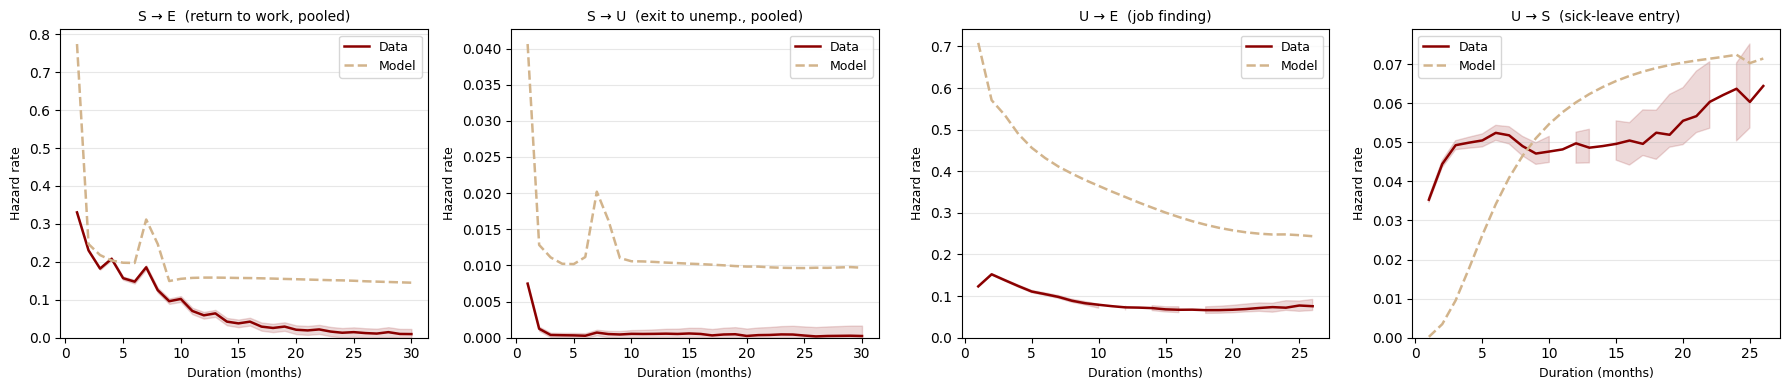

In [78]:
est.plot_fit(theta0, data_moments, ci_dict=ci_dict)

## 7. Run estimation
Nelder-Mead from `theta0`. If it converges to implausible values, try adjusting `theta0`.

In [73]:

result = est.estimate(
    data_moments,
    W              = W_se,
    theta0         = theta0,
    nm_maxiter     = 5000,
    progress_every = 5,
)
print(result['table'])


Nelder-Mead  (22 parameters)
  eval     5  |  best Q = 0.550409
  eval    10  |  best Q = 0.532127
  eval    15  |  best Q = 0.532127
  eval    20  |  best Q = 0.532127
  eval    25  |  best Q = 0.532127
  iter    25 evals  |  best Q = 0.532127
  iter    27 evals  |  best Q = 0.500549
  iter    28 evals  |  best Q = 0.500549
  eval    30  |  best Q = 0.500549
  iter    30 evals  |  best Q = 0.500549
  iter    31 evals  |  best Q = 0.500549
  iter    32 evals  |  best Q = 0.500549
  iter    33 evals  |  best Q = 0.500549
  iter    34 evals  |  best Q = 0.500549
  eval    35  |  best Q = 0.500549
  iter    35 evals  |  best Q = 0.500549
  iter    36 evals  |  best Q = 0.500549
  iter    37 evals  |  best Q = 0.500549
  iter    38 evals  |  best Q = 0.500549
  iter    39 evals  |  best Q = 0.500549
  eval    40  |  best Q = 0.500549
  iter    40 evals  |  best Q = 0.500549
  iter    41 evals  |  best Q = 0.500549
  iter    42 evals  |  best Q = 0.500549
  iter    43 evals  |  best Q = 0.5

/Users/sophiebune/Library/Mobile Documents/com~apple~CloudDocs/POLIT/Kandidat/Speciale/speciale/Code/Estimation.py:489: RuntimeWarning: Maximum number of iterations has been exceeded.
  nm_result = minimize(


                                        description   estimate  lower_bound  \
parameter                                                                     
gamma                         search cost curvature   0.693642         0.30   
iota                      work disutility curvature   0.818803         0.30   
chi                  participation cost coefficient   0.485681         0.00   
rho_h                      health AR(1) persistence   0.783675         0.50   
sigma_h                        health shock std dev   0.461165         0.05   
delta_h_S       health recovery drift on sick leave   0.065817        -0.10   
delta0_doc                   medical gate intercept   0.164684        -0.20   
delta1_doc              medical gate slope (health)   0.257634        -1.00   
delta2_doc         medical gate curvature (health²)   0.000208        -2.00   
b_sick_low   intermediate benefit post-reassessment   0.607874         0.20   
delta0_low         P(reduced benefit | h) intercept 

## 8. Simulated vs empirical hazards at estimates

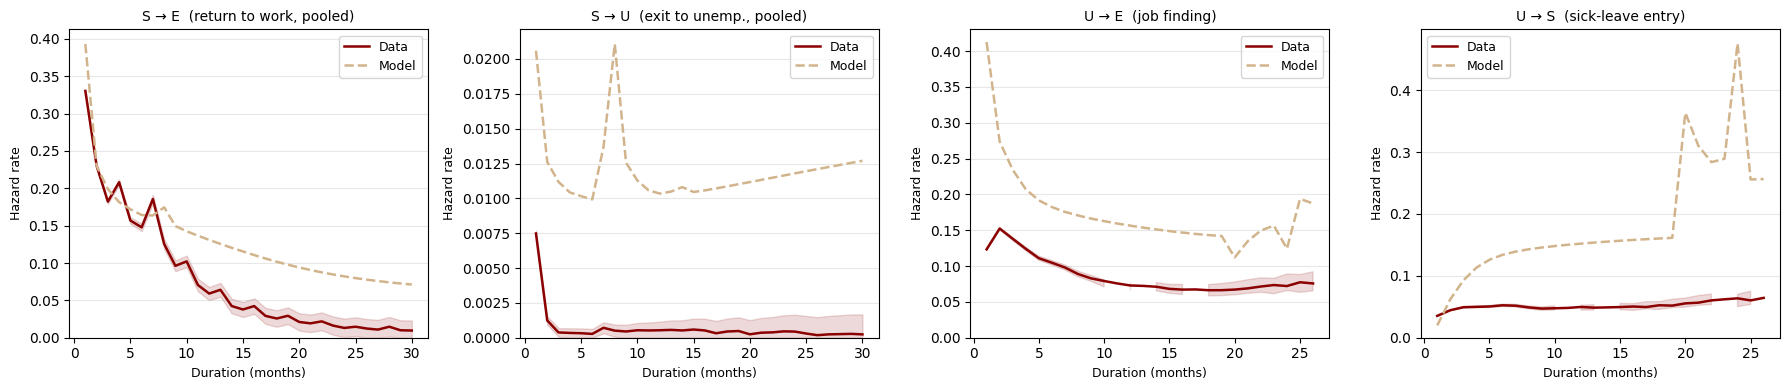

In [74]:
est.plot_fit(result['theta'], data_moments, ci_dict=ci_dict)

## 9. Moment fit table

In [75]:
fit = moment_fit_table(est.compute_moments(result['theta']), data_moments)
display(fit)

,data,model,deviation,rel_dev_%
moment,,,,
hz_se_d01,0.330428,0.393194,0.062766,18.995275
hz_se_d02,0.230212,0.230023,-0.000189,-0.082018
hz_se_d03,0.182215,0.199084,0.016869,9.257479
hz_se_d04,0.208169,0.181488,-0.026681,-12.817023
hz_se_d05,0.156924,0.171950,0.015026,9.575388
...,...,...,...,...
hz_us_d22,0.060326,0.283755,0.223429,370.371159
hz_us_d23,0.062078,0.289220,0.227141,365.894508
hz_us_d24,0.063676,0.475634,0.411958,646.958540


## 10. Re-estimation with optimal weighting matrix
Once you have a good first-round estimate, compute the efficient weighting matrix W* = Ω⁻¹  
and re-estimate. This up-weights precisely measured moments and gives correct standard errors.

In [76]:

# W_opt   = est.optimal_weight_matrix(result['theta'], data_moments, n_bootstrap=200)
# result2 = est.estimate(data_moments, W=W_opt, theta0=result['theta'])
# est.plot_fit(result2['theta'], data_moments)


## 11. Standard errors

In [77]:
# table = est.results_table(result['theta'], data_moments=data_moments,
#                            W=W_se, compute_se=True)
# display(table)